Compare the firn filters from Christo, shift the filters to the left and save, and compare the filters to the existing log-logistic filter I've been using.

In [1]:
from methane_noise_forcing import io
from hydra import compose, initialize
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from astropy.timeseries import LombScargle
from methane_noise_forcing.naming import generate_noise_realization_name
from pathlib import Path
from methane_noise_forcing.core import FirnFilter

In [2]:
with initialize(version_base=None, config_path="../../configs"):  # configs with data paths
    cfg = compose(config_name="config", overrides=[
        "+noise=white_noise_ar1",
        "++noise.duration_timeseries=4750",
        "+firn_kernel=log_logistic_wais",])

In [3]:
colors = {
    "wdc05a": "tab:blue",
    "wdc06a": "tab:orange",
    "wais": "tab:blue",
    "gisp2": "tab:green",
    "neem": "tab:cyan",
}

# EDA on firn filters, view spectral properties

In [4]:
input_path = Path(cfg.paths.firn_filters_root)
firn_filters_from_christo = pd.read_csv(input_path / "age_dist_raw.csv")
firn_filter_names = ["neem", "wais", "gisp2"]

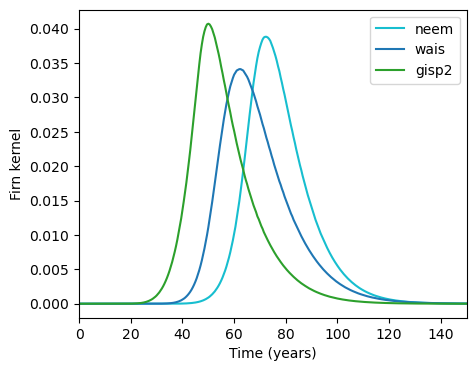

In [5]:
# compare firn filters
fig, ax = plt.subplots(figsize=(5, 4))
for name in firn_filter_names:
    ax.plot(firn_filters_from_christo["Time"], 
            firn_filters_from_christo[name],
            color=colors[name],
            label=name,)

ax.set_xlabel("Time (years)")
ax.set_ylabel("Firn kernel")
ax.set_xlim(0, 150)
ax.legend()

In [6]:
mode_center = 30.0            # years
orig        = firn_filters_from_christo  
time        = orig['Time'].values

firn_filters = pd.DataFrame({'time': time})

for name in firn_filter_names:
    # 1) find the original peak time
    mode_idx   = orig[name].idxmax()
    current_tm = orig.loc[mode_idx, 'Time']
    
    # 2) compute shift so that current_tm → mode_center
    shift = mode_center - current_tm
    
    # 3) interpolate the original filter at t - shift:
    firn_filters[name] = np.interp(
        time - shift,        # sample points
        time,                # original x-grid
        orig[name].values,   # original y-values
        left=0, right=0      # or np.nan if you’d rather
    )

# truncate at 200, ensure normalization
firn_filters = firn_filters[firn_filters['time'] <= 200]
for name in firn_filter_names:
    firn_filters[name] /= np.trapezoid(firn_filters[name], firn_filters['time'])

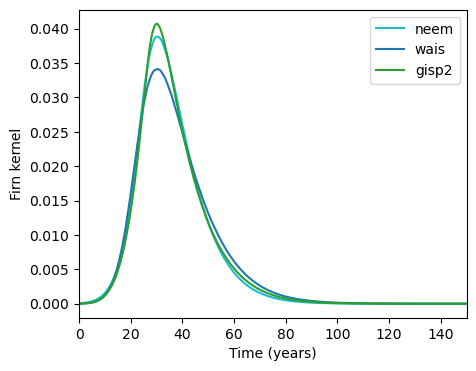

In [7]:
# compare firn filters
fig, ax = plt.subplots(figsize=(5, 4))
for name in firn_filter_names:
    ax.plot(firn_filters["time"], 
            firn_filters[name],
            color=colors[name],
            label=name,)

ax.set_xlabel("Time (years)")
ax.set_ylabel("Firn kernel")
ax.set_xlim(0, 150)
ax.legend()

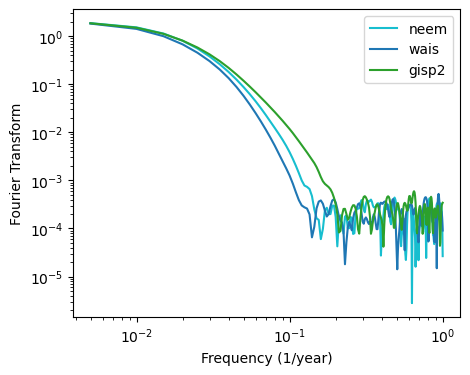

In [8]:
## calculate and plotfourier transform of the firn filters to ensure no artifacts
def calc_fourier_transform(firn_kernel, dt):
    # Compute the Fourier transform
    freq = np.fft.fftfreq(len(firn_kernel), d=dt)
    fourier_transform = np.fft.fft(firn_kernel)

    # return only positive frequencies
    pos_mask = freq > 0
    freq = freq[pos_mask]
    fourier_transform = fourier_transform[pos_mask]
    return freq, fourier_transform

fig, ax = plt.subplots(figsize=(5, 4))

for name in firn_filter_names:
    freq, fourier_transform = calc_fourier_transform(firn_filters[name], dt=0.5)

    ax.plot(freq, np.abs(fourier_transform), label=name, color=colors[name])

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Frequency (1/year)")
ax.set_ylabel("Fourier Transform")
ax.legend()

In [9]:
## save firn filters to csv
for name in firn_filter_names:
    firn_filters[["time", name]].to_csv(input_path / f"firn_filter_{name}.csv", index=False)

# fit log-logistic function to match firn filters

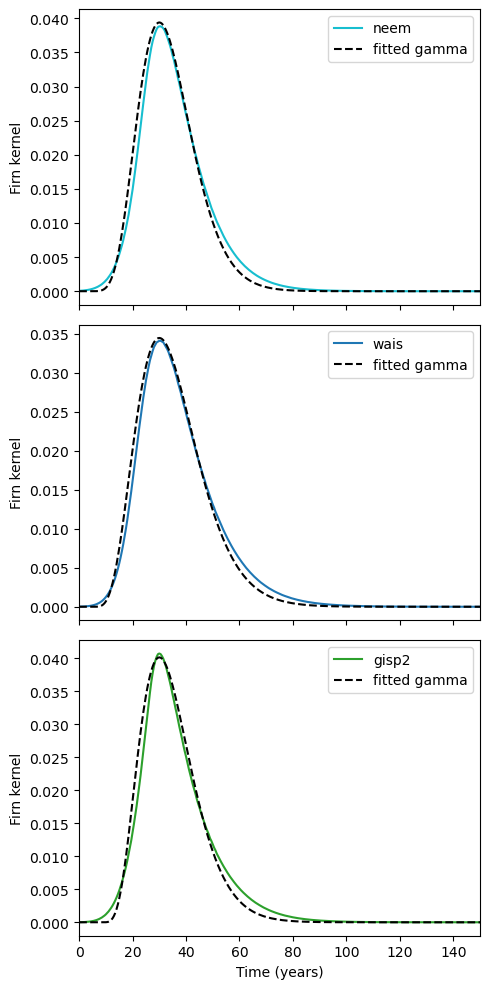

In [10]:
mode_gamma = mode_center  # years
fwhms = {
    "wais": 27,    # years
    "gisp2": 23.2,   # years
    "neem": 23.7,    # years
}
skews = {
    "wais": 0.7,
    "gisp2": 0.7,
    "neem": 0.75,
}
taper_fraction = 0  # fraction of the kernel to taper
firn_filters_gamma = {}
for name in firn_filter_names:
    fwhm = fwhms[name]
    skew = skews[name]
    firn_filters_gamma[name] = FirnFilter.fit_gamma(
        mode=mode_gamma,
        fwhm=fwhm,
        skew=skew,
        t_max=200,
        dt=0.5,
        taper_fraction=taper_fraction,  # fraction of the kernel to taper
    )

# compare fitted function to firn filters
fig, axs = plt.subplots(3, 1, figsize=(5, 10), sharex=True)
for ax, name in zip(axs, firn_filter_names):
    ax.plot(firn_filters["time"], 
            firn_filters[name],
            color=colors[name],
            label=name,)
    time = np.arange(0, 200+0.5, 0.5)
    ax.plot(time, firn_filters_gamma[name].kernel, 
            color="k", linestyle="--", label="fitted gamma")
    
    ax.set_ylabel("Firn kernel")
    ax.set_xlim(0, 150)
    ax.legend()

axs[-1].set_xlabel("Time (years)")
plt.tight_layout()

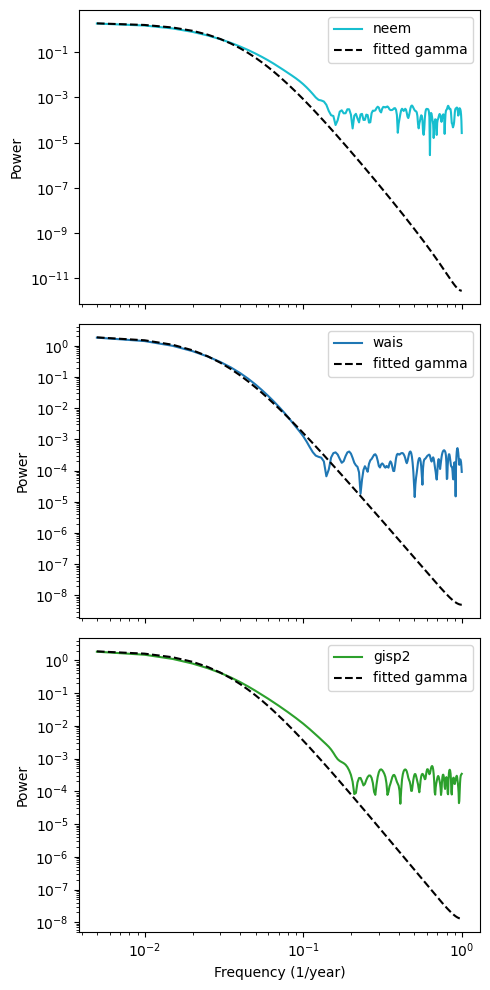

In [11]:
# compare fourier transform of the fitted function to firn filters
fig, axs = plt.subplots(3, 1, figsize=(5, 10), sharex=True)
for ax, name in zip(axs, firn_filter_names):
    freq, fourier_transform = calc_fourier_transform(firn_filters[name], dt=0.5)
    ax.plot(freq, np.abs(fourier_transform), label=name, color=colors[name])

    freq_fit, fourier_transform_fit = calc_fourier_transform(firn_filters_gamma[name].kernel, dt=0.5)
    ax.plot(freq_fit, np.abs(fourier_transform_fit), 
            label=f"fitted gamma", color="k", linestyle="--")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Power")
    ax.legend()

axs[2].set_xlabel("Frequency (1/year)")
plt.tight_layout()

The generated gamma filters are similar to the OSU firn filters, but they lack the spectral artifacts that the OSU filters have at high frequencies (>10^-1 year^-1).